In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, random
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------
# PATH CONFIG -- auto-detects Kaggle input path so you don't need to
# hardcode the dataset slug. Falls back to local paths if not on Kaggle.
# ---------------------------------------------------------------
def _find_kaggle_data_root():
    # Known exact path for this dataset -- checked first
    explicit_path = Path("/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data")
    if (explicit_path / "w_d_1").exists():
        return explicit_path
    # Fallback auto-detect in case Kaggle mounts it under a different path
    # (e.g. plain /kaggle/input/<slug>/ on some notebook setups)
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return None
    for depth_glob in ("*/w_d_1", "*/*/w_d_1", "*/*/*/w_d_1"):
        hits = list(kaggle_input.glob(depth_glob))
        if hits:
            return hits[0].parent
    return None

_kaggle_root = _find_kaggle_data_root()
if _kaggle_root is not None:
    print(f"Kaggle environment detected -- data root: {_kaggle_root}")
    RAW_DATA_DIRS = {
        "w_d_1": _kaggle_root / "w_d_1",
        "w_d_2": _kaggle_root / "w_d_2",
        "w_d_3": _kaggle_root / "w_d_3",
    }
    PROCESSED_DIR = Path("/kaggle/working/processed")
else:
    # local / non-Kaggle fallback -- edit these if running elsewhere
    RAW_DATA_DIRS = {
        "w_d_1": Path("./w_d_1"),
        "w_d_2": Path("./w_d_2"),
        "w_d_3": Path("./w_d_3"),
    }
    PROCESSED_DIR = Path("./processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def find_processed_file(filename):
    """Locate a processed artifact by FILENAME ONLY (e.g. "daily_sample.parquet"),
    not a full path -- pass a full path by mistake and this still recovers by
    taking just the basename. Searches, in order: this session's working dir,
    common Kaggle "Notebook Output" mount layouts (including the
    /kaggle/input/datasets/<owner>/<slug>/ convention), then a last-resort
    recursive search under /kaggle/input. Always returns a FILE, never a
    directory (a common gotcha: Kaggle datasets can mirror folder structure,
    so a bare glob hit can be a directory of the same name)."""
    filename = Path(filename).name  # forgiving of accidental full paths

    candidates = [PROCESSED_DIR / filename]

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        patterns = [
            f"*/processed/{filename}",
            f"*/{filename}",
            f"datasets/*/*/processed/{filename}",
            f"datasets/*/*/{filename}",
        ]
        for pattern in patterns:
            candidates.extend(kaggle_input.glob(pattern))

    for c in candidates:
        if c.is_file():
            return c

    # Last resort: recursive search (slower, but catches unexpected nesting)
    if kaggle_input.exists():
        for hit in kaggle_input.rglob(filename):
            if hit.is_file():
                return hit

    raise FileNotFoundError(
        f"'{filename}' not found under {PROCESSED_DIR} or /kaggle/input. "
        "Run the prerequisite notebook first in this same session, or attach its "
        "saved Output as a data source via Add Data > Your Work > Notebook Output Files."
    )

HOURLY_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall", "snow_depth", "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Kaggle environment detected -- data root: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data


In [3]:
daily = pd.read_parquet(find_processed_file("daily_sample.parquet"))
city_meta = pd.read_csv(find_processed_file("city_metadata.csv"))
daily = daily.merge(city_meta, on="city", how="left")
print("Loaded:", daily.shape)
daily.head()

Loaded: (206560, 28)


,city,date,temp_mean,temp_max,temp_min,apparent_temp_mean,humidity_mean,dew_point_mean,precipitation_sum,rain_sum,snowfall_sum,pressure_msl_mean,surface_pressure_mean,cloud_cover_mean,cloud_cover_low_mean,cloud_cover_mid_mean,cloud_cover_high_mean,wind_speed_10m_mean,wind_speed_100m_mean,wind_gusts_10m_max,wind_direction_10m_mean,n_obs,is_rainy_day,diurnal_temp_range,state,region,lat,lon
0,Agartala,2010-01-01,17.456834,23.073502,12.273499,16.672370,67.274269,10.813083,0.0,0.0,0.0,1015.095833,1013.783982,4.1000,2.208333,0.0,7.041667,7.748457,15.583154,24.119999,347.199756,24.0,False,10.800003,Tripura,Northeast,23.83,91.28
1,Agartala,2010-01-02,18.258917,24.773500,11.473500,18.026050,70.592328,12.321417,0.0,0.0,0.0,1015.016667,1013.708423,1.0375,0.000000,0.0,3.458333,7.344335,13.378307,24.480000,354.889709,24.0,False,13.300000,Tripura,Northeast,23.83,91.28
2,Agartala,2010-01-03,18.236001,25.373500,10.973500,18.392414,75.072259,13.163083,0.0,0.0,0.0,1013.566667,1012.260155,11.4375,12.708333,0.0,0.000000,6.739961,11.021474,18.359999,324.029047,24.0,False,14.400000,Tripura,Northeast,23.83,91.28
3,Agartala,2010-01-04,18.040167,23.773500,12.373500,18.319047,76.025863,13.388083,0.0,0.0,0.0,1011.520833,1010.216213,11.6250,10.083333,0.0,8.500000,6.326317,11.157768,18.359999,296.979751,24.0,False,11.400000,Tripura,Northeast,23.83,91.28
4,Agartala,2010-01-05,17.969334,24.023500,12.123500,17.894196,73.595210,12.738083,0.0,0.0,0.0,1011.658333,1010.353185,0.0000,0.000000,0.0,0.000000,7.252449,14.311562,21.599998,335.259488,24.0,False,11.900000,Tripura,Northeast,23.83,91.28


## 2. Regional comparison

In [4]:
region_avg = daily.groupby("region")[["temp_mean", "precipitation_sum", "humidity_mean",
                                       "wind_speed_10m_mean"]].mean().round(2)
region_avg

,temp_mean,precipitation_sum,humidity_mean,wind_speed_10m_mean
region,,,,
Central,25.18,2.99,57.28,9.86
East,25.95,4.62,77.05,9.38
North,22.78,1.98,59.12,9.21
Northeast,23.15,5.56,78.84,6.61
South,26.84,3.93,71.29,9.86
West,26.84,3.97,62.68,9.99


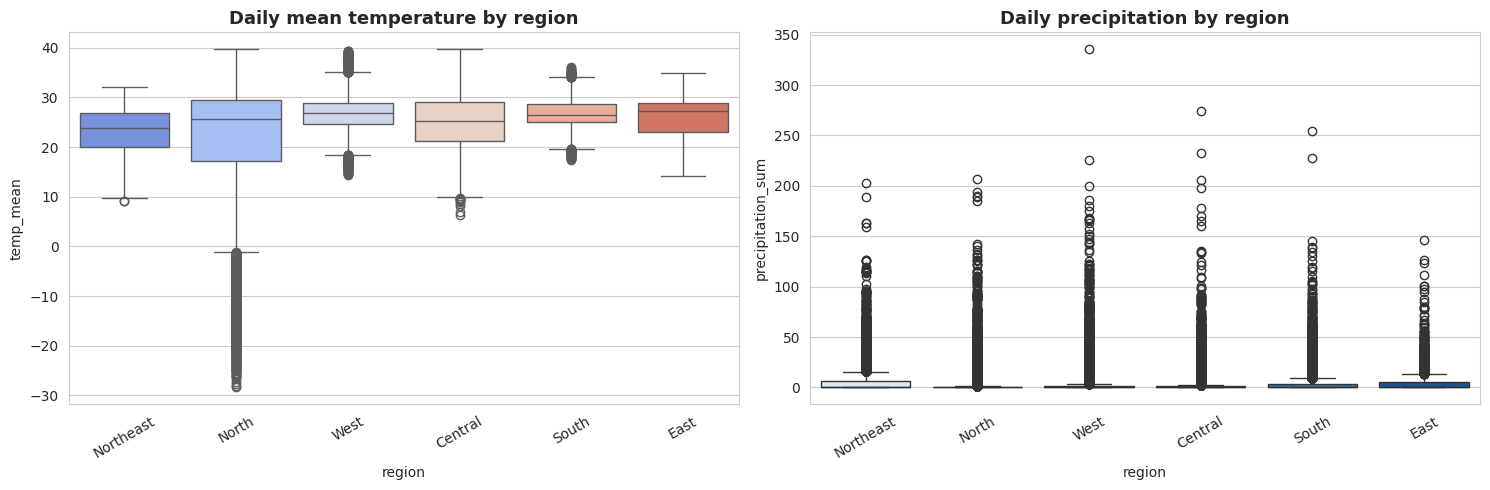

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=daily, x="region", y="temp_mean", ax=axes[0], palette="coolwarm")
axes[0].set_title("Daily mean temperature by region")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=daily, x="region", y="precipitation_sum", ax=axes[1], palette="Blues")
axes[1].set_title("Daily precipitation by region")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 3. Pseudo-geographic scatter (lon/lat scatter — no GIS dependency needed)

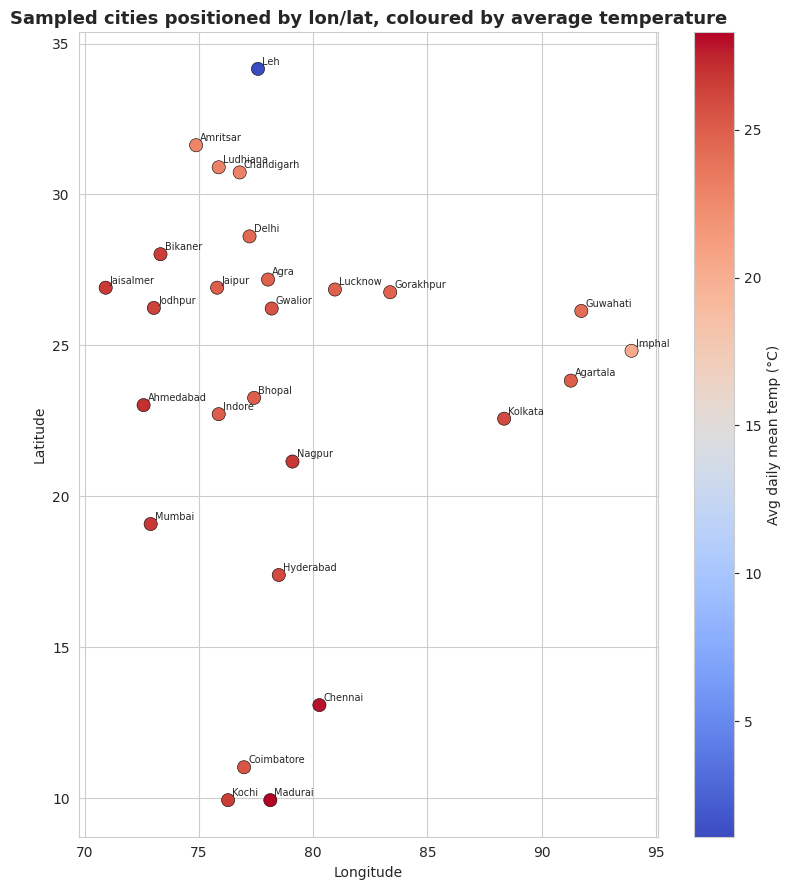

In [6]:
city_avg = daily.groupby(["city", "lat", "lon", "region"])["temp_mean"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(city_avg["lon"], city_avg["lat"], c=city_avg["temp_mean"],
                 cmap="coolwarm", s=90, edgecolor="black", linewidth=0.4)
for _, r in city_avg.iterrows():
    ax.annotate(r["city"], (r["lon"], r["lat"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, label="Avg daily mean temp (°C)")
ax.set_title("Sampled cities positioned by lon/lat, coloured by average temperature")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 4. City weather 'fingerprint' table (basis for PS2 clustering)

In [7]:
FINGERPRINT_COLS = ["temp_mean", "temp_max", "temp_min", "humidity_mean",
                     "precipitation_sum", "cloud_cover_mean", "wind_speed_10m_mean"]

fingerprint = daily.groupby("city")[FINGERPRINT_COLS].agg(["mean", "std"])
fingerprint.columns = ["_".join(c) for c in fingerprint.columns]
fingerprint = fingerprint.merge(city_meta.set_index("city")[["region", "state"]],
                                 left_index=True, right_index=True)
fingerprint.to_csv(PROCESSED_DIR / "city_weather_fingerprint.csv")
fingerprint.head()

,temp_mean_mean,temp_mean_std,temp_max_mean,temp_max_std,temp_min_mean,temp_min_std,humidity_mean_mean,humidity_mean_std,precipitation_sum_mean,precipitation_sum_std,cloud_cover_mean_mean,cloud_cover_mean_std,wind_speed_10m_mean_mean,wind_speed_10m_mean_std,region,state
city,,,,,,,,,,,,,,,,
Agartala,24.908291,3.925653,29.660496,3.297973,20.736609,5.235142,78.572711,9.752327,4.910147,10.036962,37.451071,29.450401,8.405530,3.860683,Northeast,Tripura
Agra,24.802867,6.940172,30.705587,6.748045,19.242564,7.384763,62.258585,18.771017,2.050426,6.343548,19.833702,23.416373,8.504780,2.894074,North,Uttar Pradesh
Ahmedabad,27.036222,4.504981,33.065061,4.674259,21.740071,5.038821,56.020387,18.632290,2.534314,11.062180,22.544920,29.353931,10.012512,3.370611,West,Gujarat
Amritsar,22.870351,7.646351,28.971144,7.540477,17.193946,7.794983,66.983338,17.571032,2.021166,6.030125,19.662803,20.459419,6.967003,2.261781,North,Punjab
Bhopal,24.983985,5.321981,30.523113,5.378476,19.839514,5.740134,57.243727,22.515296,3.589272,11.531169,26.803135,29.895081,9.864893,3.431737,Central,Madhya Pradesh


## 5. Clustering preview (early look ahead of PS2 modeling)
Not the final PS2 model -- just a quick sanity check that cities separate into sensible climate groups, useful to show stakeholders the concept is viable.

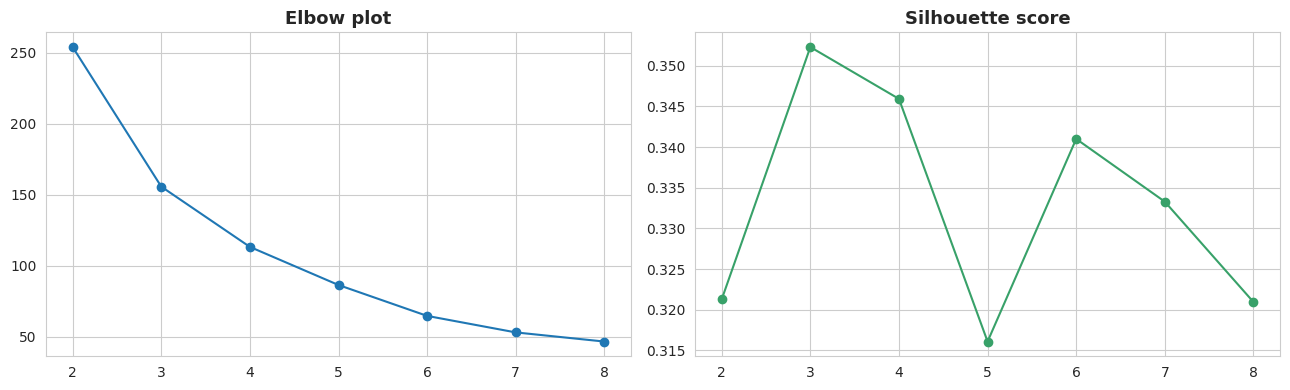

Best k by silhouette score (preview only): 3


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X = fingerprint[[c for c in fingerprint.columns if c not in ("region", "state")]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

inertias, sil_scores = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, marker="o"); axes[0].set_title("Elbow plot")
axes[1].plot(list(K_RANGE), sil_scores, marker="o", color="#38a169"); axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
print("Best k by silhouette score (preview only):", best_k)

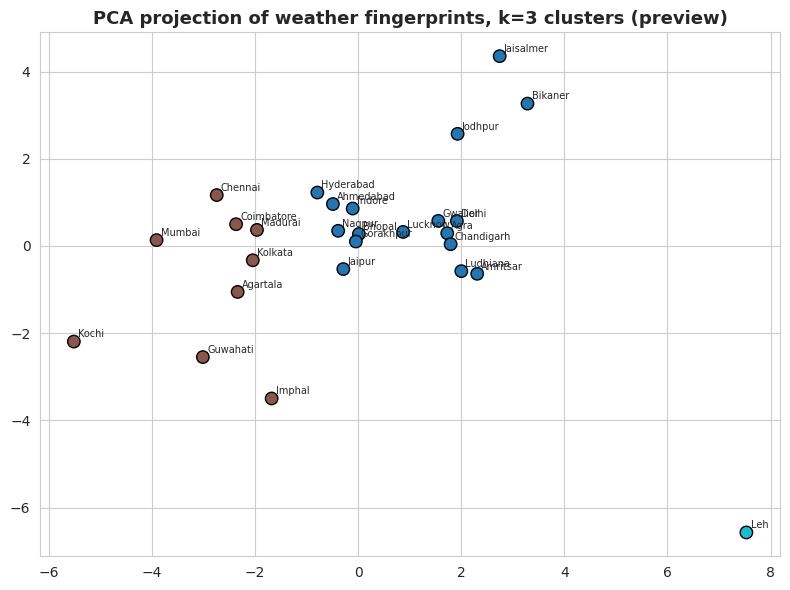

cluster  region   
0        North        11
         Central       3
         West          2
         South         1
1        South         4
         Northeast     3
         East          1
         West          1
2        North         1
Name: count, dtype: int64

In [9]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10).fit(X_scaled)
fingerprint["cluster"] = km.labels_

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=km.labels_, cmap="tab10", s=80, edgecolor="black")
for i, city in enumerate(fingerprint.index):
    ax.annotate(city, (coords[i, 0], coords[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_title(f"PCA projection of weather fingerprints, k={best_k} clusters (preview)")
plt.tight_layout()
plt.show()

fingerprint.to_csv(PROCESSED_DIR / "city_weather_fingerprint.csv")
fingerprint.groupby("cluster")["region"].value_counts()